Dataset loaded successfully!
Shape: (5572, 5)

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN



Labels:
label
ham     4825
spam     747
Name: count, dtype: int64

Converted labels:


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0



Training samples: 4457
Testing samples: 1115

TF-IDF conversion completed!
Training matrix: (4457, 5000)
Testing matrix: (1115, 5000)

Model training completed!

MODEL RESULTS
Accuracy: 97.22%

Classification Report:
                  precision    recall  f1-score   support

Legitimate (Ham)       0.97      1.00      0.98       966
            Spam       0.99      0.80      0.88       149

        accuracy                           0.97      1115
       macro avg       0.98      0.90      0.93      1115
    weighted avg       0.97      0.97      0.97      1115



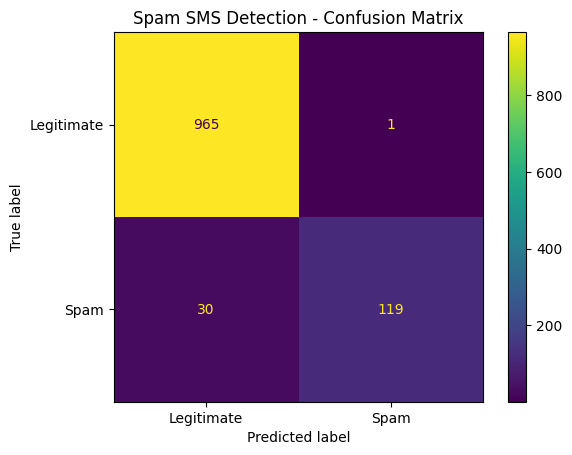


CUSTOM SMS TESTING

SMS: Congratulations! You won a free prize. Click the link now!
Prediction: SPAM

SMS: Hey, are we meeting for lunch today?
Prediction: LEGITIMATE

SMS: URGENT! You have won 100000 rupees. Call now!
Prediction: SPAM

SMS: Can you send me the notes after class?
Prediction: LEGITIMATE

Enter your own SMS: Congratulations! You have won a free prize. Call now to claim it!

Prediction: SPAM


In [5]:
# CODSOFT TASK 4 - SPAM SMS DETECTION

# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


# ==============================
# 2. LOAD DATASET
# ==============================

# Change this filename if your uploaded CSV has a different name
df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


# ==============================
# 3. CLEAN DATASET
# ==============================

# The common SMS Spam Collection dataset has:
# v1 = label
# v2 = message

df = df.iloc[:, :2]
df.columns = ["label", "message"]

# Remove missing values
df.dropna(inplace=True)

print("\nLabels:")
print(df["label"].value_counts())


# ==============================
# 4. CONVERT LABELS
# ==============================

# ham = legitimate SMS
# spam = spam SMS

df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("\nConverted labels:")
display(df.head())


# ==============================
# 5. SPLIT DATA
# ==============================

X = df["message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ==============================
# 6. TF-IDF VECTORIZATION
# ==============================

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF conversion completed!")
print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)


# ==============================
# 7. TRAIN MACHINE LEARNING MODEL
# ==============================

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("\nModel training completed!")


# ==============================
# 8. MAKE PREDICTIONS
# ==============================

y_pred = model.predict(X_test_tfidf)


# ==============================
# 9. EVALUATE MODEL
# ==============================

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL RESULTS")
print("==============================")

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate (Ham)", "Spam"]
    )
)


# ==============================
# 10. CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Spam"]
)

disp.plot()
plt.title("Spam SMS Detection - Confusion Matrix")
plt.show()


# ==============================
# 11. TEST YOUR OWN SMS
# ==============================

def predict_sms(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "LEGITIMATE"


print("\n==============================")
print("CUSTOM SMS TESTING")
print("==============================")

test_messages = [
    "Congratulations! You won a free prize. Click the link now!",
    "Hey, are we meeting for lunch today?",
    "URGENT! You have won 100000 rupees. Call now!",
    "Can you send me the notes after class?"
]

for msg in test_messages:
    print("\nSMS:", msg)
    print("Prediction:", predict_sms(msg))


# ==============================
# 12. TEST YOUR OWN MESSAGE
# ==============================

my_sms = input("\nEnter your own SMS: ")

print("\nPrediction:", predict_sms(my_sms))